In [1]:
import random
import torch
import numpy as np


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


IMG_SIZE = 224
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

full = datasets.CIFAR10(root="./data", train=True, download=True)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_raw, val_raw = random_split(full, [45000, 5000])

class DatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        x,y = self.subset[idx]
        return self.transform(x), y

train_dataset = DatasetWrapper(train_raw, train_transform)
val_dataset = DatasetWrapper(val_raw, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [3]:
from torchvision import models
import torch.nn as nn
import timm


NUM_CLASSES = 10

def get_models():
    models_dict = {}

    # CNN
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
    models_dict["ResNet18"] = resnet

    efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, NUM_CLASSES)
    models_dict["EfficientNet-B0"] = efficientnet

    # Transformers
    models_dict["ViT-Tiny"] = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
    models_dict["DeiT-Tiny"] = timm.create_model('deit_tiny_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
    models_dict["Swin-Tiny"] = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=NUM_CLASSES)

    return models_dict

models_dict = get_models()

for name in models_dict:
    models_dict[name] = models_dict[name].to(device)

print(models_dict.keys())

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dict_keys(['ResNet18', 'EfficientNet-B0', 'ViT-Tiny', 'DeiT-Tiny', 'Swin-Tiny'])


In [4]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

for name, model in models_dict.items():
    print(name, f"{count_params(model):,}")

ResNet18 11,181,642
EfficientNet-B0 4,020,358
ViT-Tiny 5,526,346
DeiT-Tiny 5,526,346
Swin-Tiny 27,527,044


In [5]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    preds, labels_all = [], []

    for x,y in tqdm(loader, leave=False):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()*x.size(0)
        preds += out.argmax(1).cpu().tolist()
        labels_all += y.cpu().tolist()

    return total_loss/len(loader.dataset), accuracy_score(labels_all,preds), f1_score(labels_all,preds,average='macro')

In [6]:
@torch.no_grad()
def eval_model(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds, labels_all = [], []

    for x,y in loader:
        x,y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out,y)

        total_loss += loss.item()*x.size(0)
        preds += out.argmax(1).cpu().tolist()
        labels_all += y.cpu().tolist()

    return total_loss/len(loader.dataset), accuracy_score(labels_all,preds), f1_score(labels_all,preds,average='macro'), labels_all, preds

In [7]:
import time
import torch.optim as optim


def train_model(model, name, epochs=3):
    print(f"\nTraining {name}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)

    history = {"val_acc":[], "time":[]}

    for ep in range(epochs):
        start = time.time()

        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1, _, _ = eval_model(model, val_loader, criterion)

        t = time.time()-start

        history["val_acc"].append(val_acc)
        history["time"].append(t)

        print(f"Epoch {ep+1}: val_acc={val_acc:.4f} time={t:.1f}s")

    return model, history

In [10]:
histories = {}
trained_models = {}

for name, model in models_dict.items():
    model, hist = train_model(model, name, epochs=3)
    histories[name] = hist
    trained_models[name] = model


Training ResNet18


Epoch 1: val_acc=0.9358 time=224.8s


Epoch 2: val_acc=0.9408 time=214.3s


Epoch 3: val_acc=0.9356 time=212.4s

Training EfficientNet-B0


Epoch 1: val_acc=0.9508 time=4055.2s


...

Epoch 3: val_acc=0.9534 time=2590.6s

Training DeiT-Tiny


Epoch 1: val_acc=0.9212 time=2678.6s


Epoch 2: val_acc=0.9358 time=2583.5s


Epoch 3: val_acc=0.9444 time=2631.6s

Training Swin-Tiny


KeyboardInterrupt: 

In [17]:
import joblib
import os

SAVE_DIR = "./saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

for name, model in trained_models.items():
    path = os.path.join(SAVE_DIR, f"{name}_weights.pkl")

    joblib.dump(model.state_dict(), path)
    print(f"Saved: {name} → {path}")

NameError: name 'trained_models' is not defined

In [16]:
hist_path = os.path.join(SAVE_DIR, "histories.pkl")

joblib.dump(histories, hist_path)
print("Histories saved")

NameError: name 'SAVE_DIR' is not defined

In [14]:
results = {}

for name, model in trained_models.items():
    loss, acc, f1, _, _ = eval_model(model, test_loader, nn.CrossEntropyLoss())

    results[name] = {
        "acc": acc,
        "f1": f1,
        "params": count_params(model)
    }

joblib.dump(results, os.path.join(SAVE_DIR, "results.pkl"))
print("Results saved")

Results saved


In [8]:
import os
import joblib

loaded_models = {}

for name in models_dict.keys():
    path = f"./saved_models/{name}_weights.pkl"

    if not os.path.exists(path):
        continue

    model = get_models()[name].to(device)
    state_dict = joblib.load(path)

    model.load_state_dict(state_dict)
    model.eval()

    loaded_models[name] = model

print("Models loaded")

Models loaded


In [9]:
results = joblib.load("./saved_models/results.pkl")

for name, r in results.items():
    print(f"{name}: acc={r['acc']:.4f}, f1={r['f1']:.4f}")

ResNet18: acc=0.9336, f1=0.9334
EfficientNet-B0: acc=0.9604, f1=0.9604
ViT-Tiny: acc=0.9506, f1=0.9507
DeiT-Tiny: acc=0.9440, f1=0.9440


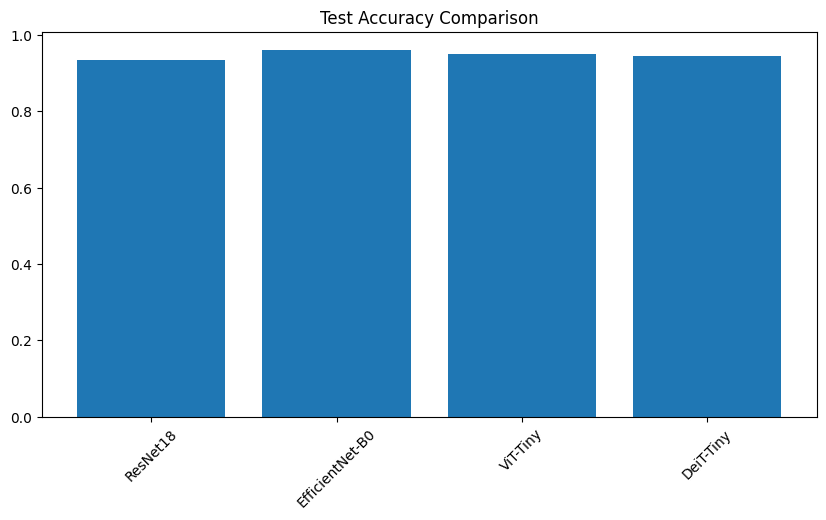

In [10]:
import matplotlib.pyplot as plt


names = list(results.keys())
accs = [results[n]["acc"] for n in names]

plt.figure(figsize=(10,5))
plt.bar(names, accs)
plt.xticks(rotation=45)
plt.title("Test Accuracy Comparison")
plt.show()

In [11]:
import joblib
import numpy as np

SAVE_DIR = "./saved_models"

# загрузка
histories = joblib.load(f"{SAVE_DIR}/histories.pkl")
results = joblib.load(f"{SAVE_DIR}/results.pkl")

print("Loaded histories and results")

Loaded histories and results


In [12]:
for name, r in results.items():
    avg_time = np.mean(histories[name]["time"])

    print(f"\n{name}")
    print(f"Accuracy: {r['acc']:.4f}")
    print(f"F1: {r['f1']:.4f}")
    print(f"Params: {r['params']:,}")
    print(f"Time/epoch: {avg_time:.2f}s")


ResNet18
Accuracy: 0.9336
F1: 0.9334
Params: 11,181,642
Time/epoch: 217.16s

EfficientNet-B0
Accuracy: 0.9604
F1: 0.9604
Params: 4,020,358
Time/epoch: 4056.03s

ViT-Tiny
Accuracy: 0.9506
F1: 0.9507
Params: 5,526,346
Time/epoch: 2539.74s

DeiT-Tiny
Accuracy: 0.9440
F1: 0.9440
Params: 5,526,346
Time/epoch: 2631.24s


In [13]:
import pandas as pd

rows = []

for name, r in results.items():
    rows.append({
        "Model": name,
        "Accuracy": round(r["acc"], 4),
        "F1": round(r["f1"], 4),
        "Params": r["params"],
        "Time/epoch (s)": round(np.mean(histories[name]["time"]), 2)
    })

df = pd.DataFrame(rows).sort_values(by="Accuracy", ascending=False)
df

,Model,Accuracy,F1,Params,Time/epoch (s)
1,EfficientNet-B0,0.9604,0.9604,4020358,4056.03
2,ViT-Tiny,0.9506,0.9507,5526346,2539.74
3,DeiT-Tiny,0.9440,0.9440,5526346,2631.24
0,ResNet18,0.9336,0.9334,11181642,217.16


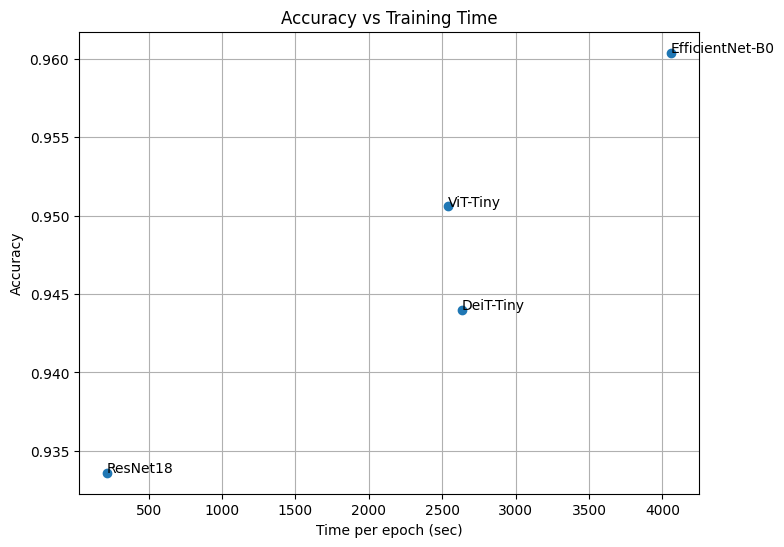

In [14]:
import matplotlib.pyplot as plt

names = []
accs = []
times = []

for name, r in results.items():
    names.append(name)
    accs.append(r["acc"])
    times.append(np.mean(histories[name]["time"]))

plt.figure(figsize=(8,6))
plt.scatter(times, accs)

for i, name in enumerate(names):
    plt.text(times[i], accs[i], name)

plt.xlabel("Time per epoch (sec)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Time")
plt.grid()
plt.show()

In [15]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

class_names = test_dataset.classes

In [16]:
def show_images_with_preds(images, labels, preds, title):
    images = images.cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    plt.figure(figsize=(12,4))
    for i in range(6):
        plt.subplot(1,6,i+1)
        plt.imshow(images[i].permute(1,2,0))
        plt.title(f"T:{class_names[labels[i]]}\nP:{class_names[preds[i]]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

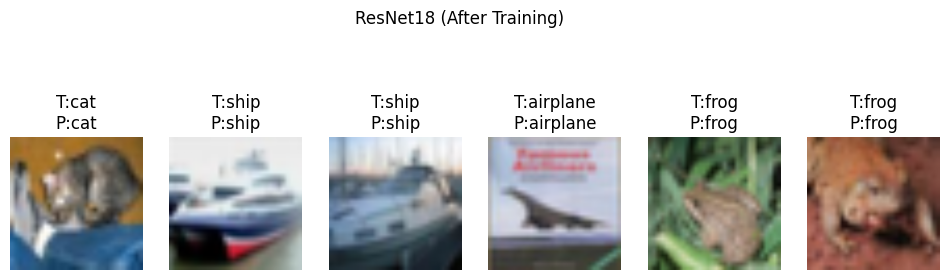

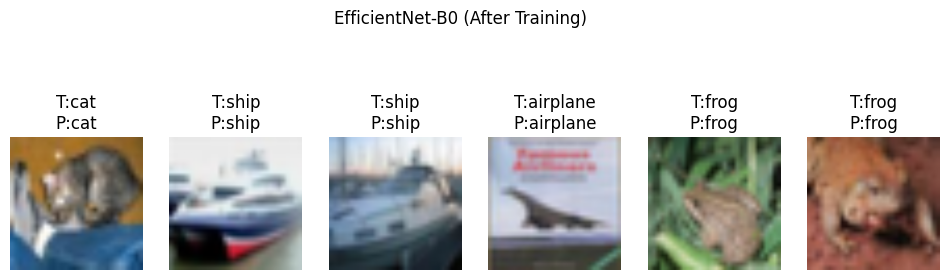

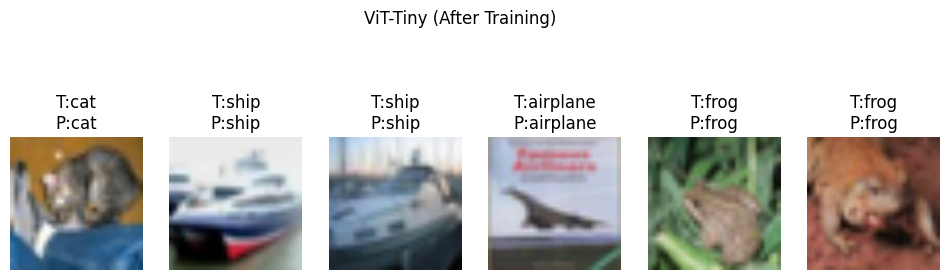

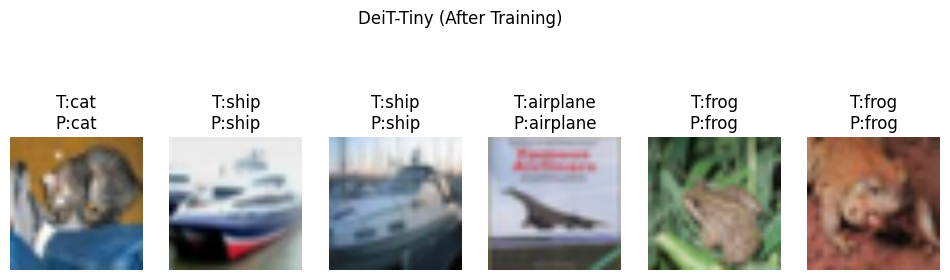

In [17]:
for name, model in loaded_models.items():
    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(1)

    show_images_with_preds(images, labels, preds, f"{name} (After Training)")


ResNet18


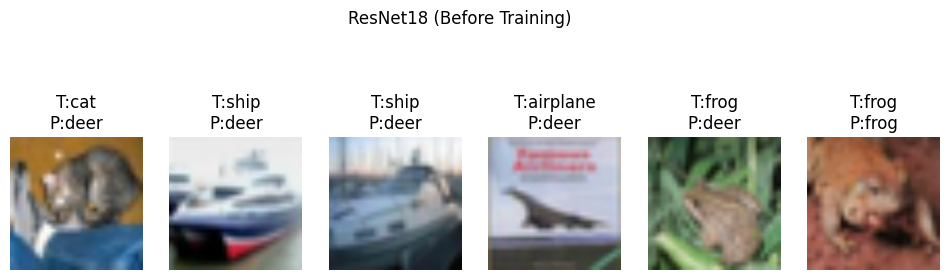

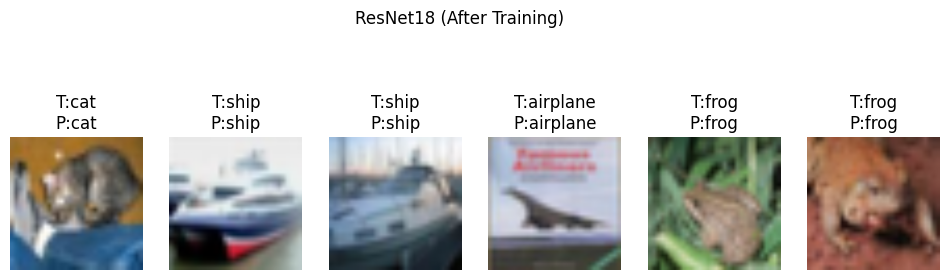


EfficientNet-B0


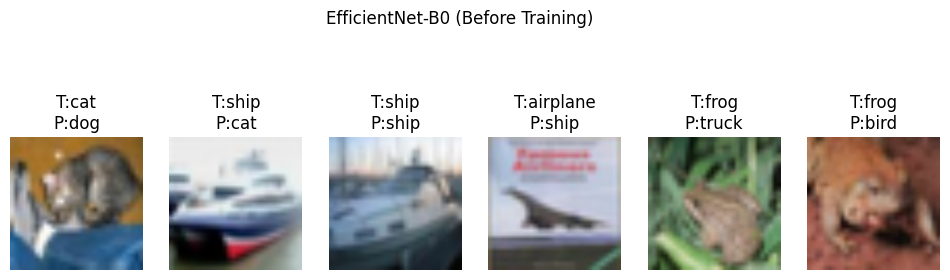

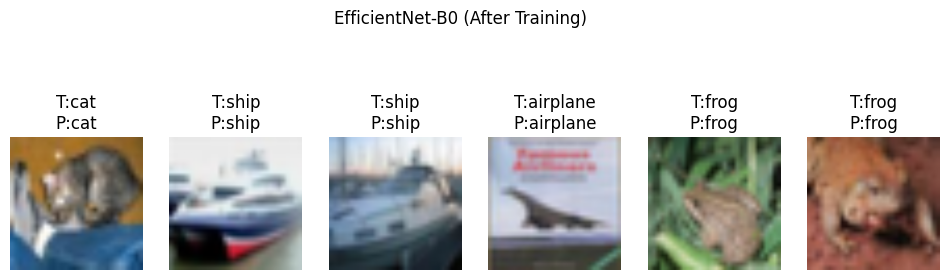


ViT-Tiny


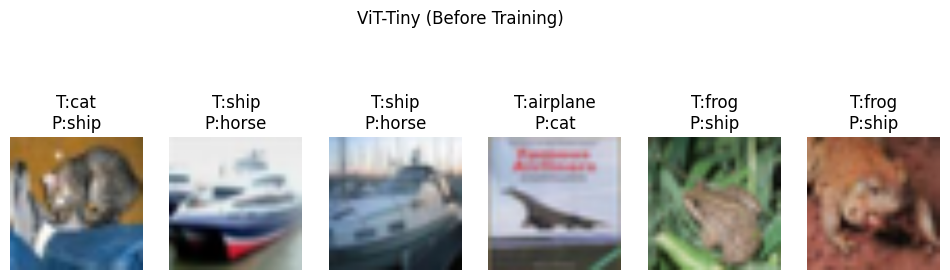

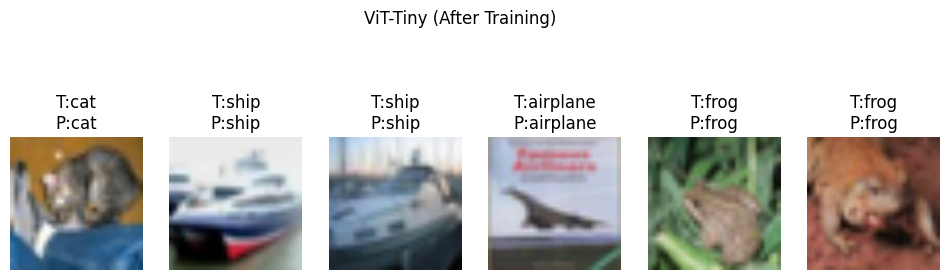


DeiT-Tiny


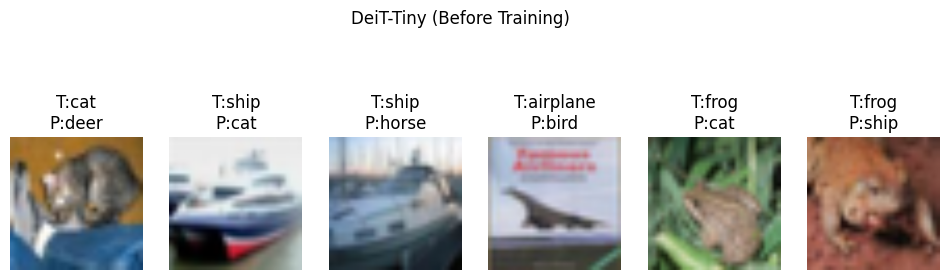

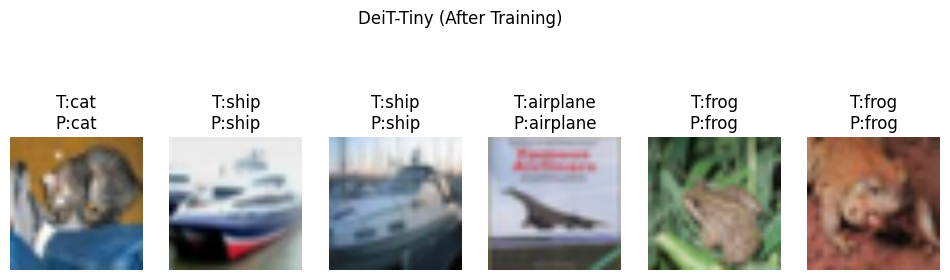

In [18]:
for name in loaded_models.keys():
    print(f"\n{name}")

    fresh_model = get_models()[name].to(device)
    fresh_model.eval()

    trained_model = loaded_models[name]

    with torch.no_grad():
        preds_before = fresh_model(images).argmax(1)
        preds_after = trained_model(images).argmax(1)

    show_images_with_preds(images, labels, preds_before, f"{name} (Before Training)")
    show_images_with_preds(images, labels, preds_after, f"{name} (After Training)")